In [1]:
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchinfo import summary

from sklearn.preprocessing import LabelEncoder

# coral
from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch

from tqdm import tqdm

import seaborn as sns

import random
import torchvision.transforms.functional as TF


sns.set_theme(style="ticks", palette="pastel", rc={'lines.linewidth': 2.5})

In [2]:
import os

folder_path = 'models/'

# Create the folder path and checkpoints directory if they don't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    
if not os.path.exists(os.path.join(folder_path, 'checkpoints')):
    os.makedirs(os.path.join(folder_path, 'checkpoints'))

In [3]:
# set device to mps
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [4]:
# modify so indices is the index of the dataframe
def read_hdf5_to_dataframe_with_index(h5_path="unified_parallel.h5"):
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]

    # Decode bytes to strings for iso3
    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]

    # Create a DataFrame with indices as the index
    df = pd.DataFrame(
        {
            "viirs_start": list(viirs_start),
            "viirs_end": list(viirs_end),
            "rgb": list(rgb),
            "figures": figures,
            "iso3": iso3_decoded,
        },
        index=indices,
    )

    df.sort_index(inplace=True)  # Ensure indices are sorted

    return df


In [5]:
# path = "../src/data/processed/flood.h5"
path = '../src/data/processed/disaster.h5'
df = read_hdf5_to_dataframe_with_index(path)

In [6]:
def replace_iso3_with_embedding(df, embedding_dim=64):
    le = LabelEncoder()
    df["iso3_id"] = le.fit_transform(df["iso3"])
    emb = nn.Embedding(
        num_embeddings=df["iso3_id"].nunique(), embedding_dim=embedding_dim
    )
    with torch.no_grad():
        embeddings = emb(torch.tensor(df["iso3_id"].values)).numpy()
    df["iso3_encoded"] = embeddings.tolist()
    # drop iso3_id
    df.drop(columns=["iso3_id"], inplace=True)
    return df, le, emb

df, le, emb = replace_iso3_with_embedding(df)

In [7]:
def create_viirs_diff_column(df):
    df["viirs_diff"] = df["viirs_end"] - df["viirs_start"]
    df.drop(columns=["viirs_start", "viirs_end"], inplace=True)
    # transpose the rgb column to have the shape (3, 224, 224) and viirs_diff to (3, 224, 224)
    df["rgb"] = df["rgb"].apply(
        lambda x: np.transpose(x, (2, 0, 1)) if len(x.shape) == 3 else x
    )
    df["viirs_diff"] = df["viirs_diff"].apply(
        lambda x: np.transpose(x, (2, 0, 1)) if len(x.shape) == 3 else x
    )
    return df
df = create_viirs_diff_column(df)

In [8]:
normalization_stats = {}


def log_and_normalize_column(df, column_name):
    df[column_name] = np.log1p(df[column_name])
    mean = df[column_name].mean()
    std = df[column_name].std()
    normalization_stats[column_name] = {"mean": mean, "std": std}
    df[column_name] = (df[column_name] - mean) / std
    return df

df = log_and_normalize_column(df, "figures")

In [9]:
log_figures = df["figures"].explode().dropna()

# Compute tertile quantiles
quantiles = log_figures.quantile([1 / 3, 2 / 3])
q1, q2 = quantiles[1 / 3], quantiles[2 / 3]
print(f"Quantiles: {q1}, {q2}")


def label_value(val):
    val = val["figures"]
    if val <= q1:
        return 0
    elif val <= q2:
        return 1
    else:
        return 2

df["label"] = df.apply(label_value, axis=1)

Quantiles: -0.5940108895301819, 0.3506198426087666


In [10]:
df.sample(20)

,rgb,figures,iso3,iso3_encoded,viirs_diff,label
2970,"[[[0.041588824, 0.041973718, 0.04243245, 0.044...",-0.334455,ECU,"[0.6080310344696045, 0.6104857921600342, -0.13...","[[-2.4899411, 0.41948342, -0.1999948, -0.97871...",1
6829,"[[[0.38558528, 0.38276932, 0.38147137, 0.38393...",-0.671750,LBY,"[-1.2960466146469116, 0.2346159815788269, -0.0...","[[-0.0054362714, -0.049055815, -0.0432207, -0....",0
11627,"[[[0.09242032, 0.077020876, 0.06131924, 0.0764...",-0.707701,USA,"[0.05115168169140816, -0.5584092140197754, -1....","[[-0.13827518, -0.096650004, -0.20209053, -0.1...",0
12610,"[[[0.118849926, 0.11861151, 0.1190758, 0.12191...",-0.067913,YEM,"[-1.8689764738082886, -1.30085027217865, -0.61...","[[-0.09542084, -0.022899061, -0.0027876794, -0...",1
5273,"[[[0.16470358, 0.1581983, 0.13341671, 0.123204...",0.782626,IND,"[-0.2173394113779068, -1.3245093822479248, -0....","[[0.9825868, 0.86763424, 0.9206057, 0.87946194...",2
3164,"[[[0.21670647, 0.21459883, 0.21425349, 0.21516...",2.246014,ETH,"[0.5479794144630432, 0.5530092716217041, -0.09...","[[8.757319e-05, 0.0021058656, 0.038107548, 0.0...",2
10931,"[[[0.28204393, 0.27588958, 0.2730951, 0.256940...",0.087322,TCD,"[-1.0289111137390137, -0.30009618401527405, 2....","[[-0.17986266, -0.17911187, -0.13481356, -0.13...",1
9983,"[[[1.1187, 1.1215061, 1.1024529, 1.0883011, 1....",-0.237584,RUS,"[-0.3706323504447937, -1.002439022064209, 1.12...","[[-0.37213552, -0.1488585, -0.06906521, -0.287...",1
3239,"[[[0.03886215, 0.038839392, 0.036862113, 0.043...",0.504340,ETH,"[0.5479794144630432, 0.5530092716217041, -0.09...","[[-0.12350793, 0.05837202, 0.04883784, -0.0292...",2
5764,"[[[0.03837488, 0.03669807, 0.041690268, 0.0537...",1.058930,IND,"[-0.2173394113779068, -1.3245093822479248, -0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",2


- Neural network

In [11]:
class MultiBranchCNNOrdinal(nn.Module):
    def __init__(self, output_dim=3):  
        super().__init__()

        self.rgb_model = models.resnet50(pretrained=True)
        self.rgb_model.fc = nn.Identity() 
        rgb_output_dim = 2048

        self.rgb_proj = nn.Sequential(
            nn.Linear(rgb_output_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

        self.viirs_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),  # Output shape: (batch_size, 64)
        )

        self.mlp = nn.Sequential(
            nn.Linear(64 + 64 + 64, 128),  # RGB + VIIRS + country_embedding
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.coral = CoralLayer(64, num_classes=output_dim)

    def forward(
        self, rgb_img, viirs_img, country_embedding
    ): 
        rgb_feat = self.rgb_model(rgb_img)
        rgb_proj = self.rgb_proj(rgb_feat)

        viirs_feat = self.viirs_cnn(viirs_img)

        fused = torch.cat(
            [rgb_proj, viirs_feat, country_embedding], dim=1
        ) 
        features = self.mlp(fused)

        return self.coral(features)

- data loader

In [12]:
target_size = (224, 224) 


class JointTransform:
    def __init__(self, target_size=target_size):
        self.target_size = target_size
        self.resize_rgb = transforms.Resize(
            target_size,
            interpolation=transforms.InterpolationMode.BILINEAR,
            antialias=False,
        )
        self.color_jitter = transforms.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
        )
        # self.normalize_rgb = transforms.Normalize(
        #     mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        # )
        self.normalize_viirs = transforms.Normalize(mean=[0], std=[1])

    def __call__(self, rgb, viirs):
        # Resize only RGB (PIL)
        rgb = self.resize_rgb(rgb)
        # rgb = self.color_jitter(rgb)

        # Random horizontal flip
        if random.random() > 0.5:
            rgb = TF.hflip(rgb)
            viirs = TF.hflip(viirs)

        # Random vertical flip
        if random.random() > 0.5:
            rgb = TF.vflip(rgb)
            viirs = TF.vflip(viirs)

        # Normalize
        # rgb = self.normalize_rgb(rgb)
        viirs = self.normalize_viirs(viirs)

        return rgb, viirs


In [13]:
class IDPDatasetOrdinal(Dataset):
    def __init__(self, df, joint_transform=None, device="cpu"):
        self.df = df
        self.joint_transform = joint_transform
        self.device = device

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load tensors
        viirs = torch.tensor(self.df.iloc[idx]["viirs_diff"]).float()
        if viirs.ndim == 2:
            viirs = viirs.unsqueeze(0)  # (1, H, W)

        rgb = torch.tensor(self.df.iloc[idx]["rgb"]).float()
        if rgb.ndim == 3 and rgb.shape[0] != 3:
            rgb = rgb.permute(2, 0, 1)  # Ensure (3, H, W)

        label = torch.tensor(self.df.iloc[idx]["label"]).long()
        iso3 = self.df.iloc[idx]["iso3"]
        iso3_emb = torch.tensor(self.df.iloc[idx]["iso3_encoded"]).float()

        # Apply joint transforms
        if self.joint_transform:
            rgb, viirs = self.joint_transform(rgb, viirs)

        return (
            rgb.to(self.device),
            viirs.to(self.device),
            label.to(self.device),
            iso3,
            iso3_emb.to(self.device),
        )


In [14]:
batch_size = 32

joint_transform = JointTransform()
dataset = IDPDatasetOrdinal(df, joint_transform=joint_transform, device="mps")
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [15]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = MultiBranchCNNOrdinal(output_dim=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

summary(
    model,
    input_size=((batch_size, 3, 224, 224), (batch_size, 1, 20, 20), 
                (batch_size, 64)), 
    device=device.type,
)

/Users/su28355962/Documents/codes/migration-estimation/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/su28355962/Documents/codes/migration-estimation/.venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Layer (type:depth-idx)                        Output Shape              Param #
MultiBranchCNNOrdinal                         [32, 2]                   --
├─ResNet: 1-1                                 [32, 2048]                --
│    └─Conv2d: 2-1                            [32, 64, 112, 112]        9,408
│    └─BatchNorm2d: 2-2                       [32, 64, 112, 112]        128
│    └─ReLU: 2-3                              [32, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [32, 64, 56, 56]          --
│    └─Sequential: 2-5                        [32, 256, 56, 56]         --
│    │    └─Bottleneck: 3-1                   [32, 256, 56, 56]         75,008
│    │    └─Bottleneck: 3-2                   [32, 256, 56, 56]         70,400
│    │    └─Bottleneck: 3-3                   [32, 256, 56, 56]         70,400
│    └─Sequential: 2-6                        [32, 512, 28, 28]         --
│    │    └─Bottleneck: 3-4                   [32, 512, 28, 28]         379,392

In [16]:
def coral_criterion(logits, labels, num_classes):
    levels = levels_from_labelbatch(labels, num_classes=num_classes).to(logits.device)
    return coral_loss(logits, levels)


def train_one_epoch(model, dataloader, optimizer, num_classes, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for rgb_imgs, viirs_imgs, labels, _, iso3_emb in tqdm(dataloader, desc="Training"):
        rgb_imgs, viirs_imgs, labels, iso3_emb = (
            rgb_imgs.to(device),
            viirs_imgs.to(device),
            labels.to(device),
            iso3_emb.to(device)
        )

        optimizer.zero_grad()
        logits = model(rgb_imgs, viirs_imgs, iso3_emb)
        loss = coral_criterion(logits, labels, num_classes)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        # Prediction from logits (ordinal decode)
        pred = torch.sum(torch.sigmoid(logits) > 0.5, dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc


def validate(model, dataloader, num_classes, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for rgb_imgs, viirs_imgs, labels, _, iso3_emb in tqdm(dataloader, desc="Validating"):
            rgb_imgs, viirs_imgs, labels, iso3_emb = (
                rgb_imgs.to(device),
                viirs_imgs.to(device),
                labels.to(device),
                iso3_emb.to(device)
            )
            logits = model(rgb_imgs, viirs_imgs, iso3_emb)
            loss = coral_criterion(logits, labels, num_classes)

            running_loss += loss.item() * labels.size(0)

            pred = torch.sum(torch.sigmoid(logits) > 0.5, dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

In [17]:
num_classes = 3  # Adjust based on your dataset
num_epochs = 400

model = MultiBranchCNNOrdinal(output_dim=num_classes).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-6)

best_val_acc = 0.0

In [ ]:
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, num_classes, device
    )
    val_loss, val_acc = validate(model, val_loader, num_classes, device)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "./models/checkpoints/best_model_ordinal.pth")
        print("✅ Best model saved.")


In [18]:
model = MultiBranchCNNOrdinal(output_dim=num_classes).to(device)

# Load saved weights
# model.load_state_dict(
#     torch.load("./models/checkpoints/best_model_ordinal.pth", map_location=device)
# )
model.load_state_dict(
    torch.load("./models/checkpoints/best_model_ordinal_best.pth", map_location=device)
)
model.eval()

MultiBranchCNNOrdinal(
  (rgb_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequen

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for rgb_imgs, viirs_imgs, labels, _, iso3_emb in test_loader:
        rgb_imgs = rgb_imgs.to(device)
        viirs_imgs = viirs_imgs.to(device)
        labels = labels.to(device)
        iso3_emb = iso3_emb.to(device)

        logits = model(rgb_imgs, viirs_imgs, iso3_emb)

        # CORAL prediction: count how many sigmoid outputs > 0.5
        preds = torch.sum(torch.sigmoid(logits) > 0.5, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


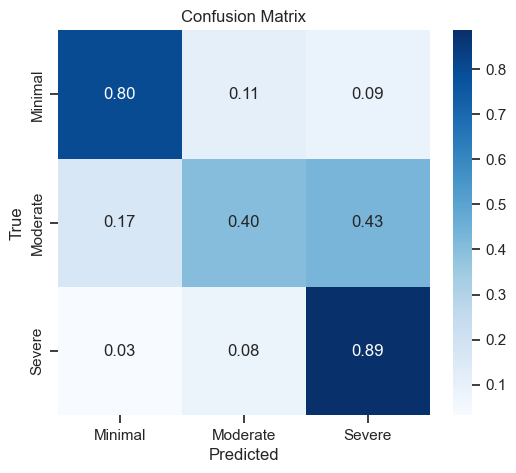

In [20]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
class_names = ["Minimal", "Moderate", "Severe"]

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
),
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
# save to pdf
plt.savefig("cm.pdf")
plt.show()

In [21]:
# classification report
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

     Minimal       0.81      0.80      0.80       438
    Moderate       0.66      0.40      0.50       409
      Severe       0.64      0.89      0.74       429

    accuracy                           0.70      1276
   macro avg       0.70      0.70      0.68      1276
weighted avg       0.70      0.70      0.69      1276

